# Dependencies and Imports

In [2]:
# Install required libraries
!pip install gymnasium highway-env stable-baselines3 torch matplotlib imageio

# For video rendering
!apt-get install -y ffmpeg

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


In [ ]:
import gymnasium as gym
import highway_env
from stable_baselines3 import PPO
from tqdm import trange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

import torch
import imageio
from google.colab import files
from IPython.display import Video

In [5]:
gym.register_envs(highway_env)

# Upload Model Zip File Here

In [6]:
uploaded = files.upload()

NameError: name 'files' is not defined

# Verify Model has Low Probability of Failure

In [7]:
NUM_EPISODES = 100
successes = 0
failures = 0

collision_positions = []  # (x, y) of ego at crash
collision_speeds = []     # ego speed at crash
collision_types = []      # 'merger' or 'highway'

for episode in trange(NUM_EPISODES):
    obs, info = env.reset()
    done = truncated = False
    merger = env.unwrapped.road.vehicles[-1]  # capture reference at reset, before any steps

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle
    if getattr(vehicle, 'crashed', False):
        failures += 1
        collision_positions.append(vehicle.position.copy())
        collision_speeds.append(vehicle.speed)

        # If merger also crashed, they collided with each other
        hit_merger = merger.crashed
        collision_types.append('merger' if hit_merger else 'highway')
    else:
        successes += 1

env.close()

merger_fails  = collision_types.count('merger')
highway_fails = collision_types.count('highway')
p_fail = failures / NUM_EPISODES

print(f"Successes:      {successes}/{NUM_EPISODES}")
print(f"Failures:       {failures}/{NUM_EPISODES}")
print(f"  Merger:       {merger_fails} ({merger_fails/NUM_EPISODES*100:.2f}%)")
print(f"  Highway:      {highway_fails} ({highway_fails/NUM_EPISODES*100:.2f}%)")
print(f"P(failure) ≈    {p_fail:.4f}  ({p_fail*100:.2f}%)")

  0%|          | 0/100 [00:00<?, ?it/s]


NameError: name 'env' is not defined

# Fuzzing Helper Functions: Run Rollout + Evaluate Proposal

In [55]:
def evaluate_proposal(delay_prob = 0.01, NUM_EPISODES = 100):
    model = PPO.load("final_model.zip")
    env = gym.make("merge-v0", render_mode="rgb_array") # Added render_mode
    device = model.device

    failure_logps = []
    mlf_logp = -np.inf
    mlf_frames = None

    for episode in trange(NUM_EPISODES):
        failed, _, logp, _, frames = run_rollout(env, model, delay_prob)
        if failed:
          failure_logps.append(logp)
          if logp > mlf_logp:
              mlf_logp = logp
              mlf_frames = frames

    env.close()

    return mlf_logp, mlf_frames, failure_logps


In [56]:
def run_rollout(env, model, delay_prob=0.01, nominal_delay_prob=0.01, record_video=True):

    obs, info = env.reset()
    done = truncated = False

    logp_nominal = 0.0
    logp_proposal = 0.0

    frames = []
    prev_action = None

    merger = env.unwrapped.road.vehicles[-1]

    while not (done or truncated):

        if record_video:
            frames.append(env.render())

        intended_action, _ = model.predict(obs, deterministic=True)

        delayed = False

        if prev_action is not None and np.random.rand() < delay_prob:
            action = prev_action
            delayed = True
        else:
            action = intended_action

        # proposal likelihood
        if delayed:
            logp_proposal += np.log(delay_prob)
        else:
            logp_proposal += np.log(1 - delay_prob)

        # nominal likelihood (fixed at 0.01)
        if delayed:
            logp_nominal += np.log(nominal_delay_prob)
        else:
            logp_nominal += np.log(1 - nominal_delay_prob)

        prev_action = action

        obs, reward, done, truncated, info = env.step(action)

    vehicle = env.unwrapped.vehicle

    failed = False
    failure_type = None

    if getattr(vehicle, "crashed", False):
        failed = True
        hit_merger = merger.crashed
        failure_type = "merger" if hit_merger else "highway"

    return failed, failure_type, logp_nominal, logp_proposal, frames

# Fuzzing

In [1]:
delay_probabilities = np.array([0.01, 0.02, 0.05, 0.75, 0.1, 0.2, 0.5])
num_rollouts_sweep = 100

action_metrics = {}
all_failure_logps = []
total_rollouts = 0
total_failures = 0

best_logp = -np.inf
best_frames = None
best_delay_prob = None


for delay_prob in delay_probabilities:

    print(f"Testing delay probability {delay_prob:.2f}")

    metric, frames, failure_logps = evaluate_proposal(delay_prob, num_rollouts_sweep)

    action_metrics[delay_prob] = metric
    if len(failure_logps) > 0:
        all_failure_logps.extend(failure_logps)
    total_rollouts += num_rollouts_sweep
    total_failures += len(failure_logps)

    if metric > best_logp:
        best_logp = metric
        best_frames = frames
        best_delay_prob = delay_prob

print("\nTotal Rollouts:", total_rollouts)
print("Total Failures:", total_failures)
print("Highest Failure Likelihood:", best_logp)
print("Correponding Delay Probability:", best_delay_prob)

NameError: name 'np' is not defined

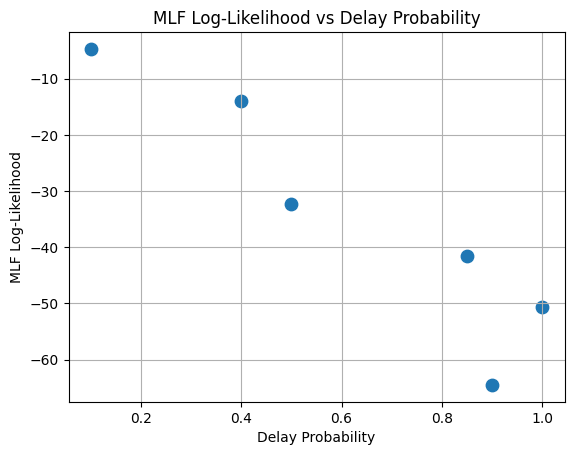

In [69]:
plt.figure()

plt.scatter(
    list(action_metrics.keys()),
    list(action_metrics.values()),
    s=80
)

plt.title("MLF Log-Likelihood vs Delay Probability")
plt.xlabel("Delay Probability")
plt.ylabel("MLF Log-Likelihood")

plt.grid(True)
plt.show()

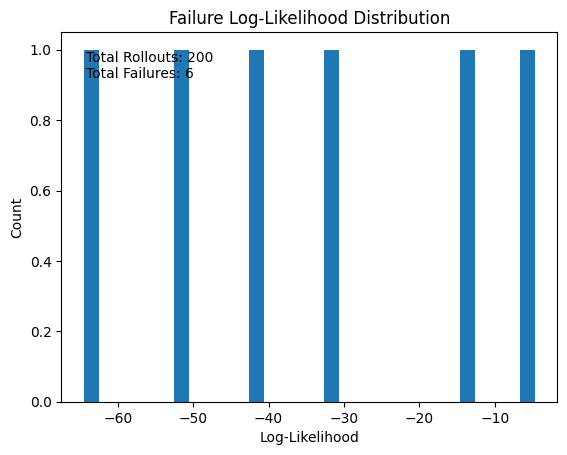

In [70]:
plt.figure()

plt.hist(all_failure_logps, bins=30)

plt.title("Failure Log-Likelihood Distribution")
plt.xlabel("Log-Likelihood")
plt.ylabel("Count")

plt.text(
    0.05, 0.95,
    f"Total Rollouts: {total_rollouts}\nTotal Failures: {total_failures}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.show()

In [71]:
if best_frames is not None:

    imageio.mimsave("most_likely_failure.mp4", best_frames, fps=30)

    print("\nMost Likely Failure Found")
    print("Delay Probability:", best_delay_prob)
    print("Failure Type:", best_failure_type)
    print("Log Likelihood:", best_logp)

else:
    print("No failures occurred during fuzzing.")


Most Likely Failure Found
Delay Probability: 0.1
Failure Type: None
Log Likelihood: -4.705673544523103


In [72]:
Video("most_likely_failure.mp4", embed=True)